In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import glob
import re
from pathlib import Path
from datetime import datetime

### Read the contour points

In [2]:
def read_contour(contour_file = "contour30sp.csv"):
    df = pd.read_csv(contour_file)

    ds = xr.Dataset(
        coords={
            "point": np.arange(len(df))
        },
        data_vars={
            "lon":      ("point", df["contour30s_lon"].to_numpy()),
            "lat":      ("point", df["contour30s_lat"].to_numpy()),
            "x":        ("point", df["contour30s_x"].to_numpy()),
            "y":        ("point", df["contour30s_y"].to_numpy()),
            "normal_x": ("point", df["normals30_x"].to_numpy()),
            "normal_y": ("point", df["normals30_y"].to_numpy()),
        }
    )
    return ds

In [3]:
contour_ds = read_contour()
contour_ds

<xarray.Dataset> Size: 24kB
Dimensions:   (point: 425)
Coordinates:
  * point     (point) int64 3kB 0 1 2 3 4 5 6 7 ... 418 419 420 421 422 423 424
Data variables:
    lon       (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44 -82.44
    lat       (point) float64 3kB 29.96 29.96 29.96 29.96 ... 25.56 25.54 25.52
    x         (point) float64 3kB -1.759e+05 -1.739e+05 ... 3.554e+05 3.557e+05
    y         (point) float64 3kB 3.335e+06 3.335e+06 ... 2.826e+06 2.824e+06
    normal_x  (point) float64 3kB -0.0164 -0.01563 -0.01645 ... 0.9893 0.9907
    normal_y  (point) float64 3kB 0.9999 0.9999 0.9999 ... 0.1557 0.1459 0.1358

In [4]:
def attach_contour(ds, contour_ds):
    ds = ds.assign_coords(
        lon=("point", contour_ds["lon"].values),
        lat=("point", contour_ds["lat"].values),
        x=("point", contour_ds["x"].values),
        y=("point", contour_ds["y"].values),
    )
    ds["normal_x"] = ("point", contour_ds["normal_x"].values)
    ds["normal_y"] = ("point", contour_ds["normal_y"].values)
    return ds

In [5]:
def calc_hm0(ds):
    f = ds["freq"].values
    theta = np.deg2rad(ds["dir"].values)
    S = ds["spec"].values
    dtheta = np.abs( theta[1]-theta[0] )
    print('dtheta:', dtheta, 'radians:', np.rad2deg(dtheta), 'deg')

    Sf = np.sum(S, axis=-1) * dtheta
    print(np.shape(Sf))
    m0 = np.trapezoid(Sf, f, axis=-1)
    hm0 = 4.0 * np.sqrt(m0)

    ds["m0"] = (("time", "point"), m0)
    ds["hm0"] = (("time", "point"), hm0)
    ds["m0"].attrs["units"] = "m^2"
    ds["hm0"].attrs["units"] = "m"

    return ds

### Read Hurrywave spectra

In [6]:
def read_hurrywave_2dspec(nc_path, contour_ds=None):
    ds0 = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)

    time = ds0["time"].values
    f = ds0["sigma"].values                    # Hz
    omega = f * 2.0 * np.pi                   # rad/s
    dir_from_deg = ds0["theta"].values        # degrees from

    # native shape: (time, stations, theta, sigma)
    S = ds0["point_spectrum2d"].values

    # your working code converts to energy density using omega
    S = S * omega[np.newaxis, np.newaxis, np.newaxis, :]

    # convert from per-(rad/s) to per-Hz
    S = S * (2.0 * np.pi)

    # reorder to (time, point, freq, dir)
    S = np.transpose(S, (0, 1, 3, 2))

    ds = xr.Dataset(
        coords={
            "time": time,
            "point": np.arange(S.shape[1]),
            "freq": f,
            "dir": dir_from_deg,
        },
        data_vars={
            "spec": (("time", "point", "freq", "dir"), S),
        },
        attrs={
            "model": "Hurrywave",
            "dir_convention": "from",
            "spec_units": "m^2/Hz/rad",
        }
    )

    if contour_ds is not None:
        ds = attach_contour(ds, contour_ds)

    return ds

In [7]:
data_dir = "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/helene89pervmax/"
nc_path = data_dir+"hurrywave_sp2.nc"
ds_hw = read_hurrywave_2dspec(nc_path)
ds_hw = calc_hm0(ds_hw)
print('Hurrywave')
time = ds_hw["time"].values   # datetime64 array
dt = (time[1] - time[0])   # numpy.timedelta64
dt_seconds = dt / np.timedelta64(1, "s")
print( 'Start: ', time[0] )
print( 'End  : ', time[-1] )
print( 'Deltat:', dt_seconds, 's')
print( 'Hm0:',np.max( ds_hw['hm0'].values ))
ds_hw

dtheta: 0.17453294 radians: 10.0 deg
(115, 425, 12)
Hurrywave
Start:  2024-09-23T00:00:00.000000000
End  :  2024-09-27T18:00:00.000000000
Deltat: 3600.0 s
Hm0: 11.771618


<xarray.Dataset> Size: 85MB
Dimensions:  (time: 115, point: 425, freq: 12, dir: 36)
Coordinates:
  * time     (time) datetime64[ns] 920B 2024-09-23 ... 2024-09-27T18:00:00
  * point    (point) int64 3kB 0 1 2 3 4 5 6 7 ... 418 419 420 421 422 423 424
  * freq     (freq) float32 48B 0.04 0.05032 0.06331 ... 0.3159 0.3974 0.5
  * dir      (dir) float32 144B 5.0 15.0 25.0 35.0 ... 325.0 335.0 345.0 355.0
Data variables:
    spec     (time, point, freq, dir) float32 84MB 0.0 0.0 ... 0.002424 0.002713
    m0       (time, point) float32 196kB 0.0 0.0 0.0 ... 0.2835 0.2835 0.2835
    hm0      (time, point) float32 196kB 0.0 0.0 0.0 0.0 ... 2.13 2.13 2.13 2.13
Attributes:
    model:           Hurrywave
    dir_convention:  from
    spec_units:      m^2/Hz/rad

### Read the ADCIRC SWAN .spc files

In [8]:
# kind of complicated to parse the ADCIRC files...need some subroutines.

_float_re = re.compile(r"[-+]?\d*\.\d+(?:[Ee][-+]?\d+)?|[-+]?\d+(?:[Ee][-+]?\d+)?")
_int_re   = re.compile(r"[-+]?\d+")
_time_re  = re.compile(r"^\d{8}\.\d{6}$")

def _floats_in_line(s):
    return [float(x) for x in _float_re.findall(s)]

def _ints_in_line(s):
    return [int(x) for x in _int_re.findall(s)]

def _parse_swan_time(tok):
    return datetime.strptime(tok, "%Y%m%d.%H%M%S")

def _read_number_block(lines, i0, n, kind="float"):
    vals = []
    i = i0
    getvals = _floats_in_line if kind == "float" else _ints_in_line
    while len(vals) < n:
        vals.extend(getvals(lines[i]))
        i += 1
    return np.array(vals[:n]), i

def read_swan_spec_vadens_factor(spc_path):
    """
    Read SWAN .spc file and return:
      lon, lat, freqs, dirs, times, E(nt,nf,nd) in m^2/Hz/rad
    """
    lines = Path(spc_path).read_text(errors="ignore").splitlines()

    # ---- header blocks ----
    for i, ln in enumerate(lines):
        s = ln.strip()

        if s.startswith("LONLAT"):
            lon, lat = _floats_in_line(lines[i+2])[:2]

        elif s.startswith("AFREQ"):
            nf = int(lines[i+1].split()[0])
            freqs, _ = _read_number_block(lines, i+2, nf, kind="float")
            freqs = freqs.astype(float)

        elif s.startswith("CDIR"):
            nd = int(lines[i+1].split()[0])
            dirs, _ = _read_number_block(lines, i+2, nd, kind="float")
            dirs = dirs.astype(float)

    # ---- time records ----
    times = []
    E_list = []

    i = 0
    while i < len(lines):
        tok = lines[i].strip().split()
        if tok and _time_re.match(tok[0]):
            t = _parse_swan_time(tok[0])

            while not lines[i].strip().startswith("FACTOR"):
                i += 1

            factor = _floats_in_line(lines[i+1])[0]
            A, i = _read_number_block(lines, i+2, nf*nd, kind="int")
            A = A.reshape(nf, nd)

            E = factor * A * (180.0 / np.pi)   # m^2/Hz/rad

            times.append(t)
            E_list.append(E)
        else:
            i += 1

    E = np.stack(E_list, axis=0)   # (nt, nf, nd)

    return {
        "lon": lon,
        "lat": lat,
        "freqs": freqs,
        "dirs": dirs,
        "times": times,
        "E": E,
    }

In [9]:
def read_adcirc_2dspec(spec_files):
    spec_files = list(spec_files)
    ds_list = []

    for ipt, fp in enumerate(spec_files):
        rec = read_swan_spec_vadens_factor(fp)

        time = np.asarray(rec["times"])
        freq = np.asarray(rec["freqs"])
        dir_from_deg = np.asarray(rec["dirs"])   # degrees from
        S = np.asarray(rec["E"])                 # (time, freq, dir)

        dsi = xr.Dataset(
            coords={
                "time": time,
                "point": [ipt],
                "freq": freq,
                "dir": dir_from_deg,
            },
            data_vars={
                "spec": (("time", "point", "freq", "dir"), S[:, np.newaxis, :, :]),
            }
        )
        ds_list.append(dsi)

    ds = xr.concat(ds_list, dim="point")
    ds.attrs["model"] = "ADCIRC/SWAN"
    ds.attrs["dir_convention"] = "from"
    ds.attrs["spec_units"] = "m^2/Hz/rad"

    ds = attach_contour(ds, contour_ds)

    return ds

In [10]:
spec_dir = "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/spec_files/"
spec_files = sorted(glob.glob(spec_dir + "bnd*.spc"))   # bnd1.spc ... bnd425.spc
ds_ad = read_adcirc_2dspec(spec_files)

In [11]:
ds_ad = calc_hm0(ds_ad)
time = ds_ad["time"].values   # datetime64 array
dt = (time[1] - time[0])   # numpy.timedelta64
dt_seconds = dt / np.timedelta64(1, "s")
print('ADCIRC/SWAN')
print( 'Start: ', time[0] )
print( 'End  : ', time[-1] )
print( 'Deltat:', dt_seconds, 's')
print( 'Hm0:',np.max( ds_ad['hm0'].values ))
ds_ad

dtheta: 0.17453292519943292 radians: 9.999999999999998 deg
(145, 425, 41)
ADCIRC/SWAN
Start:  2024-09-25T00:00:00.000000000
End  :  2024-09-28T00:00:00.000000000
Deltat: 1800.0 s
Hm0: 12.164944309496104


<xarray.Dataset> Size: 729MB
Dimensions:   (time: 145, point: 425, freq: 41, dir: 36)
Coordinates:
  * time      (time) datetime64[ns] 1kB 2024-09-25 ... 2024-09-28
  * point     (point) int64 3kB 0 1 2 3 4 5 6 7 ... 418 419 420 421 422 423 424
  * freq      (freq) float64 328B 0.0314 0.0345 0.038 ... 1.174 1.291 1.42
  * dir       (dir) float64 288B 5.0 15.0 25.0 35.0 ... 325.0 335.0 345.0 355.0
    lon       (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44 -82.44
    lat       (point) float64 3kB 29.96 29.96 29.96 29.96 ... 25.56 25.54 25.52
    x         (point) float64 3kB -1.759e+05 -1.739e+05 ... 3.554e+05 3.557e+05
    y         (point) float64 3kB 3.335e+06 3.335e+06 ... 2.826e+06 2.824e+06
Data variables:
    spec      (time, point, freq, dir) float64 728MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    normal_x  (point) float64 3kB -0.0164 -0.01563 -0.01645 ... 0.9893 0.9907
    normal_y  (point) float64 3kB 0.9999 0.9999 0.9999 ... 0.1557 0.1459 0.1358
    m0        (time, point) float64 493kB 0.006338 0.005755 ... 0.1278 0.1277
    hm0       (time, point) float64 493kB 0.3185 0.3034 0.2925 ... 1.43 1.429
Attributes:
    model:           ADCIRC/SWAN
    dir_convention:  from
    spec_units:      m^2/Hz/rad

### Read COAWST/WW3 from THREDDS

In [12]:
def read_coawst_2dspec(url, engine="netcdf4"):
    ds0 = xr.open_dataset(url)

    time = ds0["time"].values
    freq = ds0["frequency"].values
    # note that directions are not sorted
    dir_from_deg = ds0["direction"].values   # degrees from

    # native shape: (time, station, frequency, direction)
    S = ds0["efth"].values

    ds = xr.Dataset(
        coords={
            "time": time,
            "point": np.arange(S.shape[1]),
            "freq": freq,
            "dir": dir_from_deg,
        },
        data_vars={
            "spec": (("time", "point", "freq", "dir"), S),
        },
        attrs={
            "model": "COAWST/WW3",
            "dir_convention": "from",
            "spec_units": "m^2/Hz/rad",
        }
    )
    
    ds = attach_contour(ds, contour_ds)

    return ds

In [13]:
dap_url = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "ww3.202409_spec.nc"
)
ds_cw = read_coawst_2dspec( dap_url )
ds_cw = calc_hm0(ds_cw)
time = ds_cw["time"].values   # datetime64 array
dt = (time[1] - time[0])   # numpy.timedelta64
dt_seconds = dt / np.timedelta64(1, "s")
print( 'Start: ', time[0] )
print( 'End  : ', time[-1] )
print( 'Deltat:', dt_seconds, 's')
print( 'Hm0:',np.max( ds_cw['hm0'].values ))
ds_cw

dtheta: 0.17453301 radians: 10.000004 deg
(121, 425, 32)
Start:  2024-09-24T00:00:00.000000000
End  :  2024-09-29T00:00:00.000000000
Deltat: 3600.0 s
Hm0: 10.980288


<xarray.Dataset> Size: 237MB
Dimensions:   (time: 121, point: 425, freq: 32, dir: 36)
Coordinates:
  * time      (time) datetime64[ns] 968B 2024-09-24 ... 2024-09-29
  * point     (point) int64 3kB 0 1 2 3 4 5 6 7 ... 418 419 420 421 422 423 424
  * freq      (freq) float32 128B 0.038 0.0418 0.04598 ... 0.6028 0.6631 0.7294
  * dir       (dir) float32 144B 90.0 80.0 70.0 60.0 ... 130.0 120.0 110.0 100.0
    lon       (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44 -82.44
    lat       (point) float64 3kB 29.96 29.96 29.96 29.96 ... 25.56 25.54 25.52
    x         (point) float64 3kB -1.759e+05 -1.739e+05 ... 3.554e+05 3.557e+05
    y         (point) float64 3kB 3.335e+06 3.335e+06 ... 2.826e+06 2.824e+06
Data variables:
    spec      (time, point, freq, dir) float32 237MB 1.097e-21 ... 0.0001248
    normal_x  (point) float64 3kB -0.0164 -0.01563 -0.01645 ... 0.9893 0.9907
    normal_y  (point) float64 3kB 0.9999 0.9999 0.9999 ... 0.1557 0.1459 0.1358
    m0        (time, point) float32 206kB 0.01121 0.01112 ... 0.03545 0.03514
    hm0       (time, point) float32 206kB 0.4235 0.4218 0.4201 ... 0.7531 0.7498
Attributes:
    model:           COAWST/WW3
    dir_convention:  from
    spec_units:      m^2/Hz/rad

### Trim so all have same time period with hourly data

In [14]:
t_start = np.datetime64("2024-09-25T00:00:00")
t_end   = np.datetime64("2024-09-27T23:00:00")
time_hourly = np.arange(t_start, t_end + np.timedelta64(1, "h"), np.timedelta64(1, "h"))

print("ntime:", len(time_hourly))
print(time_hourly[:3], "...", time_hourly[-3:])

def trim_to_hourly(ds, time_hourly):
    """
    Trim dataset to target time range and sample onto hourly grid.
    Assumes ds has coordinate 'time'.
    """

    # restrict to window (fast)
    ds = ds.sel(time=slice(time_hourly[0], time_hourly[-1]))

    # sample to hourly using nearest (no interpolation)
    ds = ds.sel(time=time_hourly, method="nearest")

    return ds

ds_hw_t = trim_to_hourly(ds_hw, time_hourly)
ds_ad_t = trim_to_hourly(ds_ad, time_hourly)
ds_cw_t = trim_to_hourly(ds_cw, time_hourly)

for name, ds in {
    "HW": ds_hw_t,
    "ADCIRC": ds_ad_t,
    "COAWST": ds_cw_t
}.items():
    print("\n", name)
    print("shape:", ds["hm0"].shape)
    print("start:", ds.time.values[0])
    print("end  :", ds.time.values[-1])

ntime: 72
['2024-09-25T00:00:00' '2024-09-25T01:00:00' '2024-09-25T02:00:00'] ... ['2024-09-27T21:00:00' '2024-09-27T22:00:00' '2024-09-27T23:00:00']

 HW
shape: (72, 425)
start: 2024-09-25T00:00:00.000000000
end  : 2024-09-27T18:00:00.000000000

 ADCIRC
shape: (72, 425)
start: 2024-09-25T00:00:00.000000000
end  : 2024-09-27T23:00:00.000000000

 COAWST
shape: (72, 425)
start: 2024-09-25T00:00:00.000000000
end  : 2024-09-27T23:00:00.000000000


In [15]:
out_dir = 'F:/crs/proj/2025_NOPP_comparison/helene_contour_all3/'  # or wherever you want

ds_hw_t.to_netcdf(out_dir + "hurrywave_aligned.nc")
ds_ad_t.to_netcdf(out_dir + "adcirc_aligned.nc")
ds_cw_t.to_netcdf(out_dir + "coawst_aligned.nc")

print("Saved aligned datasets.")

Saved aligned datasets.


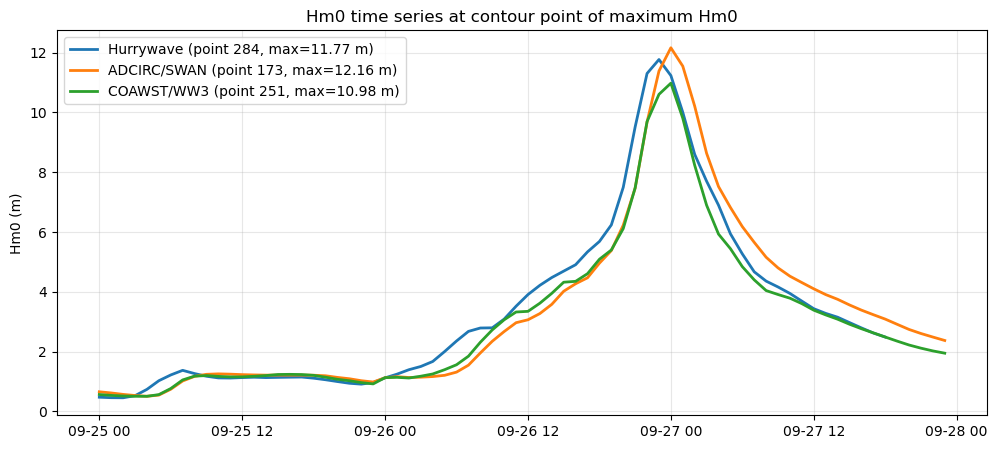

In [16]:
def plot_hm0_at_max_point(ds, ax=None, label=None):
    """
    Plot hm0(time) at the contour point where hm0 reaches its maximum value.
    Assumes ds['hm0'] has dims ('time', 'point').
    """
    hm0 = ds["hm0"].values  # (time, point)

    # index of overall max in the 2D array
    it, ip = np.unravel_index(np.nanargmax(hm0), hm0.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(ds["time"].values, hm0[:, ip], lw=2,
            label=f"{label or ds.attrs.get('model','model')} (point {ip}, max={hm0[it, ip]:.2f} m)")

    return ip, it, ax

fig, ax = plt.subplots(figsize=(12, 5))

ip_hw, it_hw, ax = plot_hm0_at_max_point(ds_hw_t, ax=ax, label="Hurrywave")
ip_ad, it_ad, ax = plot_hm0_at_max_point(ds_ad_t, ax=ax, label="ADCIRC/SWAN")
ip_cw, it_cw, ax = plot_hm0_at_max_point(ds_cw_t, ax=ax, label="COAWST/WW3")

ax.set_ylabel("Hm0 (m)")
ax.set_title("Hm0 time series at contour point of maximum Hm0")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

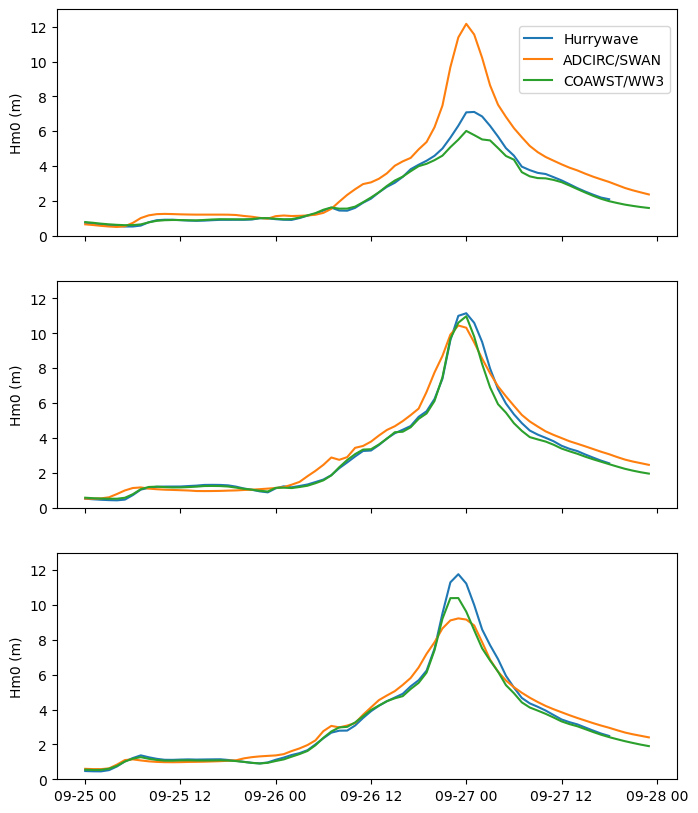

In [17]:
icp = [173, 251, 284]
fig, ax = plt.subplots(3,1,figsize=(8,10), sharex=True)
ax[0].plot( ds_hw_t['time'].values, ds_hw_t['hm0'].values[:, icp[0]], label='Hurrywave' )
ax[0].plot( ds_ad_t['time'].values, ds_ad_t['hm0'].values[:, icp[0]], label='ADCIRC/SWAN' )
ax[0].plot( ds_cw_t['time'].values, ds_cw_t['hm0'].values[:, icp[0]], label='COAWST/WW3' )
ax[0].set_ylabel("Hm0 (m)")
ax[0].set_ylim( 0, 13)
ax[1].plot( ds_hw_t['time'].values, ds_hw_t['hm0'].values[:, icp[1]] )
ax[1].plot( ds_ad_t['time'].values, ds_ad_t['hm0'].values[:, icp[1]] )
ax[1].plot( ds_cw_t['time'].values, ds_cw_t['hm0'].values[:, icp[1]] )
ax[1].set_ylabel("Hm0 (m)")
ax[1].set_ylim( 0, 13)
ax[2].plot( ds_hw_t['time'].values, ds_hw_t['hm0'].values[:, icp[2]] )
ax[2].plot( ds_ad_t['time'].values, ds_ad_t['hm0'].values[:, icp[2]] )
ax[2].plot( ds_cw_t['time'].values, ds_cw_t['hm0'].values[:, icp[2]] )
ax[2].set_ylabel("Hm0 (m)")
ax[2].set_ylim( 0, 13)
fig.legend(loc='upper right', bbox_to_anchor=(.9, .87)) # Position outside the subplots)